<a href="https://colab.research.google.com/github/Lima-Developer/machine-learning-cheat-analysis/blob/master/SVM_Algorithm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Acurácia: 1.00


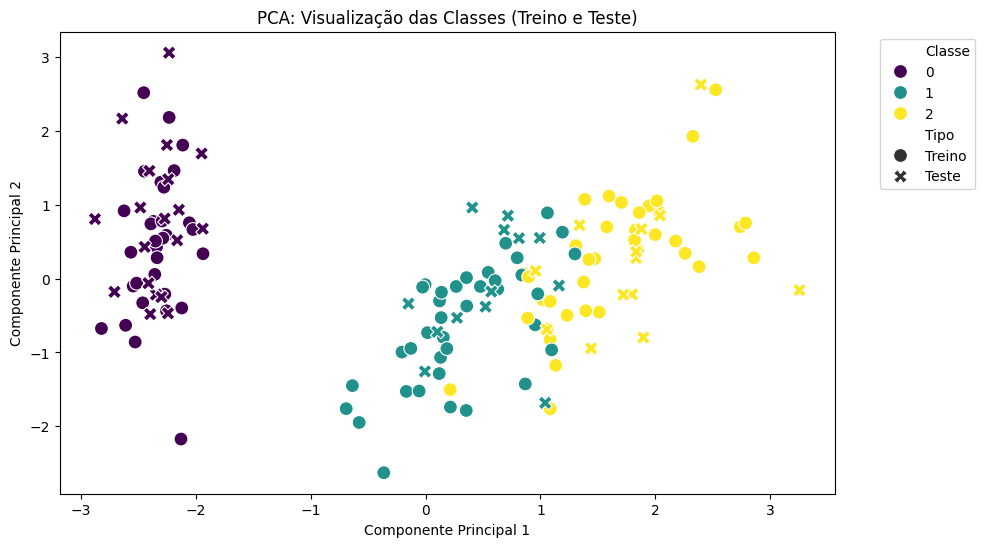

In [ ]:
!pip install scikit-learn matplotlib seaborn pandas numpy

from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Carregar dataset (ex: Iris)
iris = datasets.load_iris()
X, y = iris.data, iris.target

# Dividir em treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Normalizar dados (crucial para SVM)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Criar modelo SVM com kernel RBF
model = SVC(kernel='rbf', C=1.0, gamma='scale')
model.fit(X_train, y_train)

# Predição e avaliação
y_pred = model.predict(X_test)
print(f"Acurácia: {accuracy_score(y_test, y_pred):.2f}")

# Reduzir para 2D com PCA
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

# Criar DataFrames para treino e teste
df_train = pd.DataFrame(X_train_pca, columns=['PC1', 'PC2'])
df_train['Classe'] = y_train
df_train['Tipo'] = 'Treino'  # Coluna para diferenciar treino/teste

df_test = pd.DataFrame(X_test_pca, columns=['PC1', 'PC2'])
df_test['Classe'] = y_test
df_test['Tipo'] = 'Teste'

# Combinar os dados
df_full = pd.concat([df_train, df_test])

# Plotar
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_full,
    x='PC1',
    y='PC2',
    hue='Classe',
    style='Tipo',
    palette='viridis',
    markers={'Treino': 'o', 'Teste': 'X'},
    s=100
)

plt.title('PCA: Visualização das Classes (Treino e Teste)')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

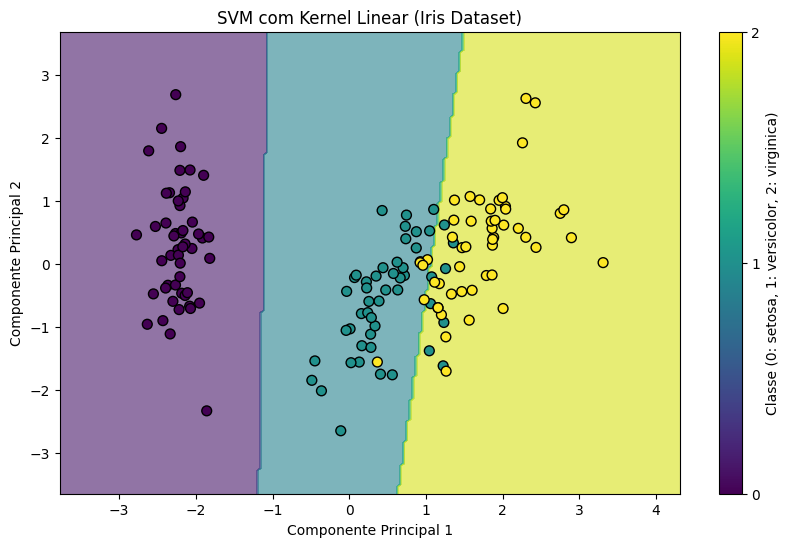

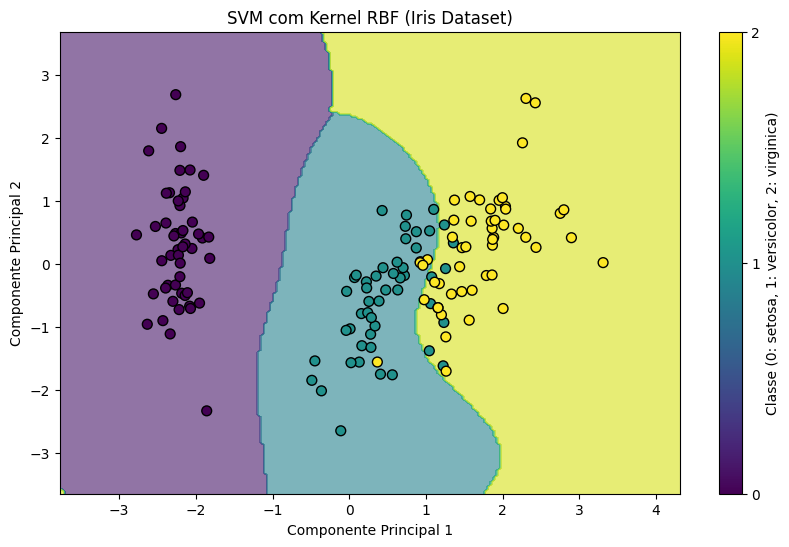

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Carregar o dataset Iris
iris = datasets.load_iris()
X, y = iris.data, iris.target

# Padronizar os dados
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Reduzir para 2D com PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Função para plotar a fronteira de decisão
def plot_iris_svm(kernel_type, title, filename):
    model = SVC(kernel=kernel_type, C=1.0, gamma='auto')
    model.fit(X_pca, y)

    # Criar grid para a fronteira
    x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
    y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Plotar
    plt.figure(figsize=(10, 6))
    plt.contourf(xx, yy, Z, alpha=0.6, cmap='viridis')
    plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis', edgecolors='k', s=50)
    plt.title(title)
    plt.xlabel('Componente Principal 1')
    plt.ylabel('Componente Principal 2')
    plt.colorbar(ticks=[0, 1, 2], label='Classe (0: setosa, 1: versicolor, 2: virginica)')
    plt.savefig(filename)  # Salvar a imagem
    plt.show()

# Gerar gráficos
plot_iris_svm('linear', 'SVM com Kernel Linear (Iris Dataset)', 'svm_iris_linear.png')
plot_iris_svm('rbf', 'SVM com Kernel RBF (Iris Dataset)', 'svm_iris_rbf.png')